## Problem Statement

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==2.2.2 scikit-learn==1.5.2 matplotlib==3.8.0 seaborn==0.13.1 imbalanced-learn==0.10.1 xgboost==1.7.2 threadpoolctl==3.5.0 -q --user

**Note:** After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.

In [1]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [2]:
df = pd.read_csv("/content/Train.csv.csv")
df_test = pd.read_csv("/content/Test.csv.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# copying data to another varaible to avoid any changes to original data
data = df.copy()
data_test = df_test.copy()

## Data Overview

- Observations
- Sanity checks

In [ ]:
# displaying the first and last 5 rows of the dataset
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.465,-4.679,3.102,0.506,-0.221,-2.033,-2.911,0.051,-1.522,3.762,-5.715,0.736,0.981,1.418,-3.376,-3.047,0.306,2.914,2.270,4.395,-2.388,0.646,-1.191,3.133,0.665,-2.511,-0.037,0.726,-3.982,-1.073,1.667,3.060,-1.690,2.846,2.235,6.667,0.444,-2.369,2.951,-3.480,0
1,3.366,3.653,0.910,-1.368,0.332,2.359,0.733,-4.332,0.566,-0.101,1.914,-0.951,-1.255,-2.707,0.193,-4.769,-2.205,0.908,0.757,-5.834,-3.065,1.597,-1.757,1.766,-0.267,3.625,1.500,-0.586,0.783,-0.201,0.025,-1.795,3.033,-2.468,1.895,-2.298,-1.731,5.909,-0.386,0.616,0
2,-3.832,-5.824,0.634,-2.419,-1.774,1.017,-2.099,-3.173,-2.082,5.393,-0.771,1.107,1.144,0.943,-3.164,-4.248,-4.039,3.689,3.311,1.059,-2.143,1.650,-1.661,1.680,-0.451,-4.551,3.739,1.134,-2.034,0.841,-1.600,-0.257,0.804,4.086,2.292,5.361,0.352,2.940,3.839,-4.309,0
3,1.618,1.888,7.046,-1.147,0.083,-1.530,0.207,-2.494,0.345,2.119,-3.053,0.460,2.705,-0.636,-0.454,-3.174,-3.404,-1.282,1.582,-1.952,-3.517,-1.206,-5.628,-1.818,2.124,5.295,4.748,-2.309,-3.963,-6.029,4.949,-3.584,-2.577,1.364,0.623,5.550,-1.527,0.139,3.101,-1.277,0
4,-0.111,3.872,-3.758,-2.983,3.793,0.545,0.205,4.849,-1.855,-6.220,1.998,4.724,0.709,-1.989,-2.633,4.184,2.245,3.734,-6.313,-5.380,-0.887,2.062,9.446,4.490,-3.945,4.582,-8.780,-3.383,5.107,6.788,2.044,8.266,6.629,-10.069,1.223,-3.230,1.687,-2.164,-3.645,6.510,0


In [ ]:
data.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071,-1.088,-0.796,-3.012,-2.288,2.807,0.481,0.105,-0.587,-2.899,8.868,1.717,1.358,-1.777,0.710,4.945,-3.100,-1.199,-1.085,-0.365,3.131,-3.948,-3.578,-8.139,-1.937,-1.328,-0.403,-1.735,9.996,6.955,-3.938,-8.274,5.745,0.589,-0.650,-3.043,2.216,0.609,0.178,2.928,1
19996,2.890,2.483,5.644,0.937,-1.381,0.412,-1.593,-5.762,2.150,0.272,-2.095,-1.526,0.072,-3.540,-2.762,-10.632,-0.495,1.720,3.872,-1.210,-8.222,2.121,-5.492,1.452,1.450,3.685,1.077,-0.384,-0.839,-0.748,-1.089,-4.159,1.181,-0.742,5.369,-0.693,-1.669,3.660,0.820,-1.987,0
19997,-3.897,-3.942,-0.351,-2.417,1.108,-1.528,-3.520,2.055,-0.234,-0.358,-3.782,2.180,6.112,1.985,-8.330,-1.639,-0.915,5.672,-3.924,2.133,-4.502,2.777,5.728,1.620,-1.700,-0.042,-2.923,-2.760,-2.254,2.552,0.982,7.112,1.476,-3.954,1.856,5.029,2.083,-6.409,1.477,-0.874,0
19998,-3.187,-10.052,5.696,-4.370,-5.355,-1.873,-3.947,0.679,-2.389,5.457,1.583,3.571,9.227,2.554,-7.039,-0.994,-9.665,1.155,3.877,3.524,-7.015,-0.132,-3.446,-4.801,-0.876,-3.812,5.422,-3.732,0.609,5.256,1.915,0.403,3.164,3.752,8.530,8.451,0.204,-7.130,4.249,-6.112,0
19999,-2.687,1.961,6.137,2.600,2.657,-4.291,-2.344,0.974,-1.027,0.497,-9.589,3.177,1.055,-1.416,-4.669,-5.405,3.720,2.893,2.329,1.458,-6.429,1.818,0.806,7.786,0.331,5.257,-4.867,-0.819,-5.667,-2.861,4.674,6.621,-1.989,-1.349,3.952,5.450,-0.455,-2.202,1.678,-1.974,0


- All the columns seem to have appropriate data types.

In [ ]:
# understanding the shape of the dataset.
data.shape

(20000, 41)

* There are 20000 rows and 41 columns in the dataset.

In [ ]:
# checking data types and number of non-null values for each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

- There are 40 float and 1 integer columns in the dataset.
- The target variable is Target, which is of integer type.
- There are some missing values in columns V1 and V2 in the dataset.

In [ ]:
# getting the summary of the dataset.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.000,-0.272,3.442,-11.876,-2.737,-0.748,1.840,15.493
V2,19982.000,0.440,3.151,-12.320,-1.641,0.472,2.544,13.089
V3,20000.000,2.485,3.389,-10.708,0.207,2.256,4.566,17.091
V4,20000.000,-0.083,3.432,-15.082,-2.348,-0.135,2.131,13.236
V5,20000.000,-0.054,2.105,-8.603,-1.536,-0.102,1.340,8.134
V6,20000.000,-0.995,2.041,-10.227,-2.347,-1.001,0.380,6.976
V7,20000.000,-0.879,1.762,-7.950,-2.031,-0.917,0.224,8.006
V8,20000.000,-0.548,3.296,-15.658,-2.643,-0.389,1.723,11.679
V9,20000.000,-0.017,2.161,-8.596,-1.495,-0.068,1.409,8.138
V10,20000.000,-0.013,2.193,-9.854,-1.411,0.101,1.477,8.108


- There are some gaps between 75% and max for many columns, which indicates existence of outliers.

In [ ]:
# checking duplicates
data.duplicated().sum()

0

- There are no duplicates in the dataset.

## Exploratory Data Analysis (EDA)

### Plotting histograms and boxplots for all the variables

In [4]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Plotting all the features at one go

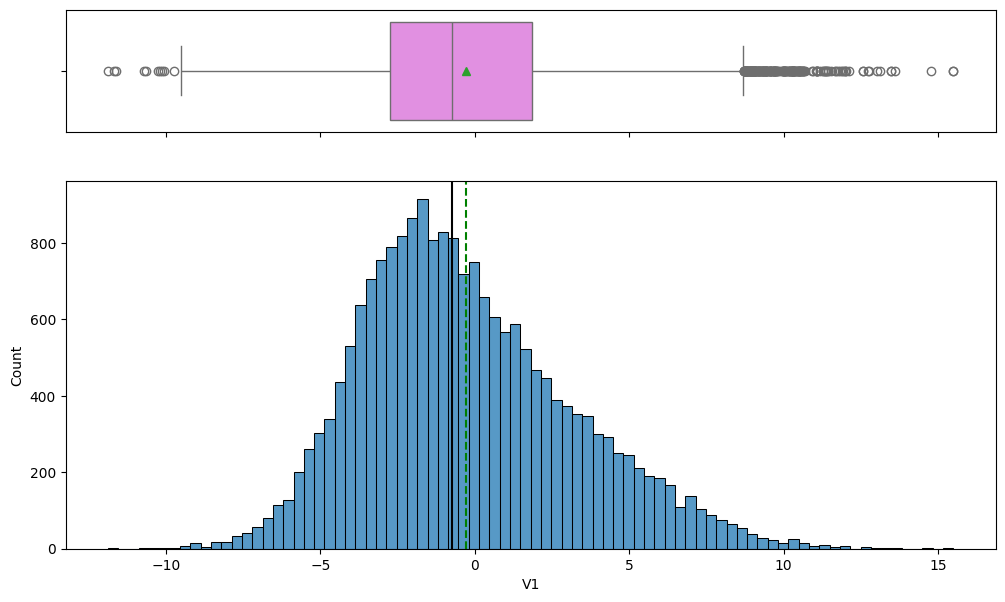

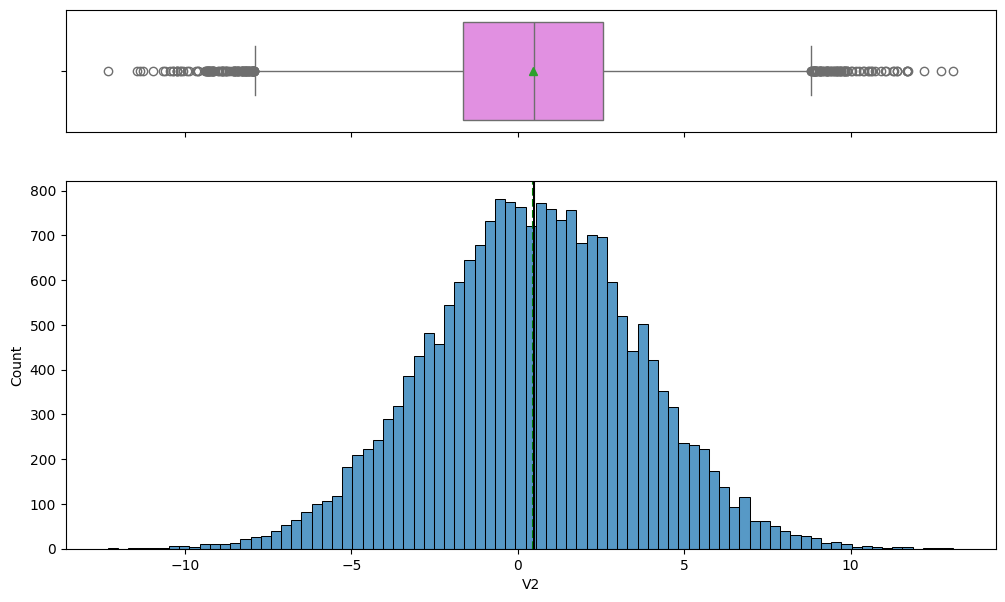

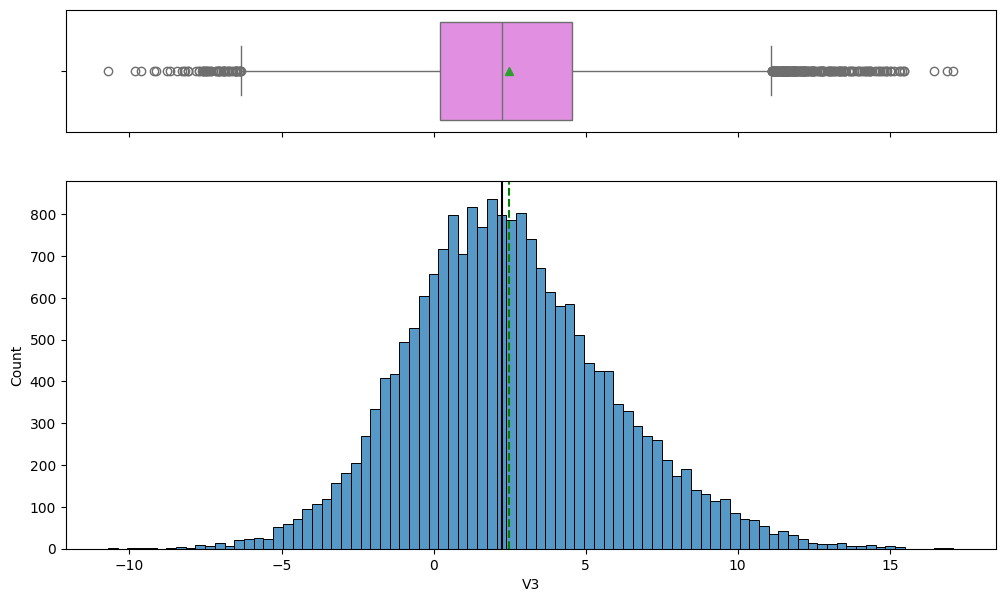

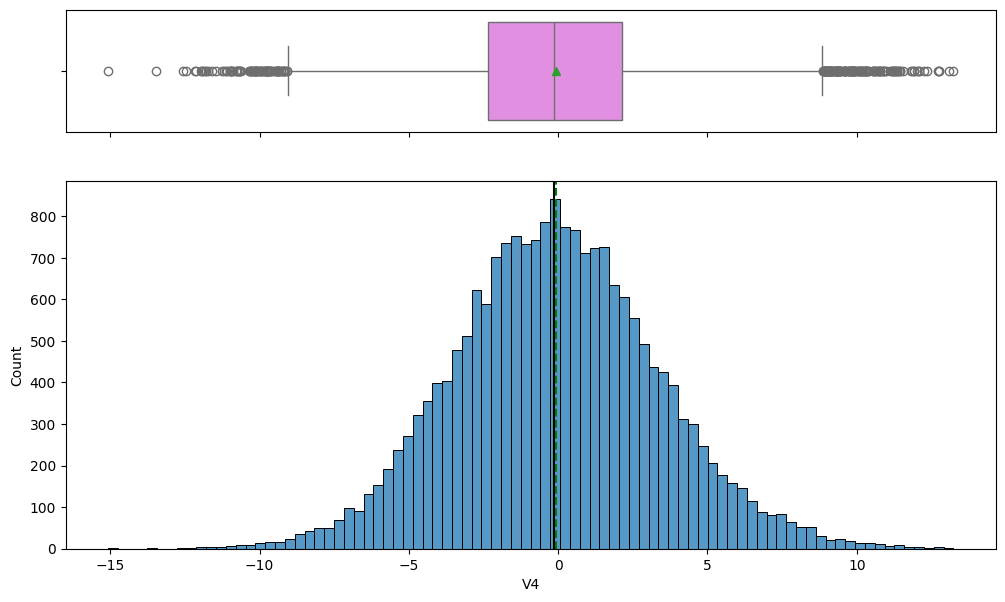

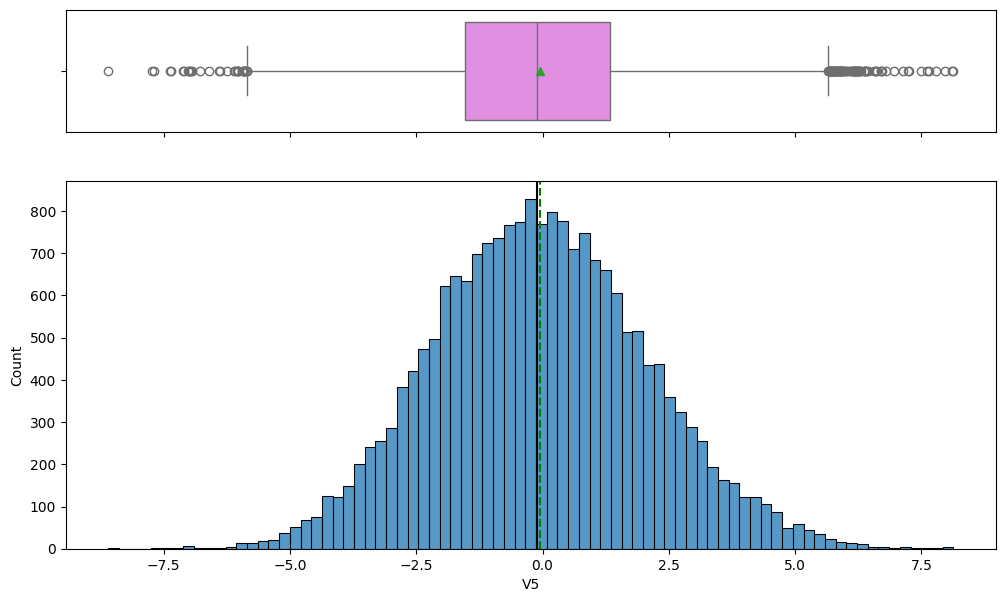

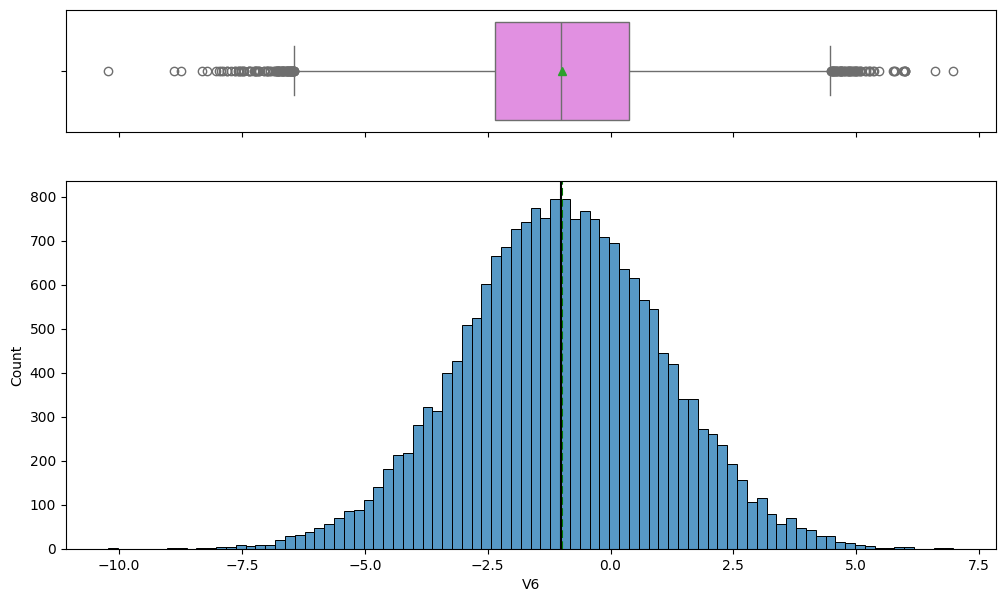

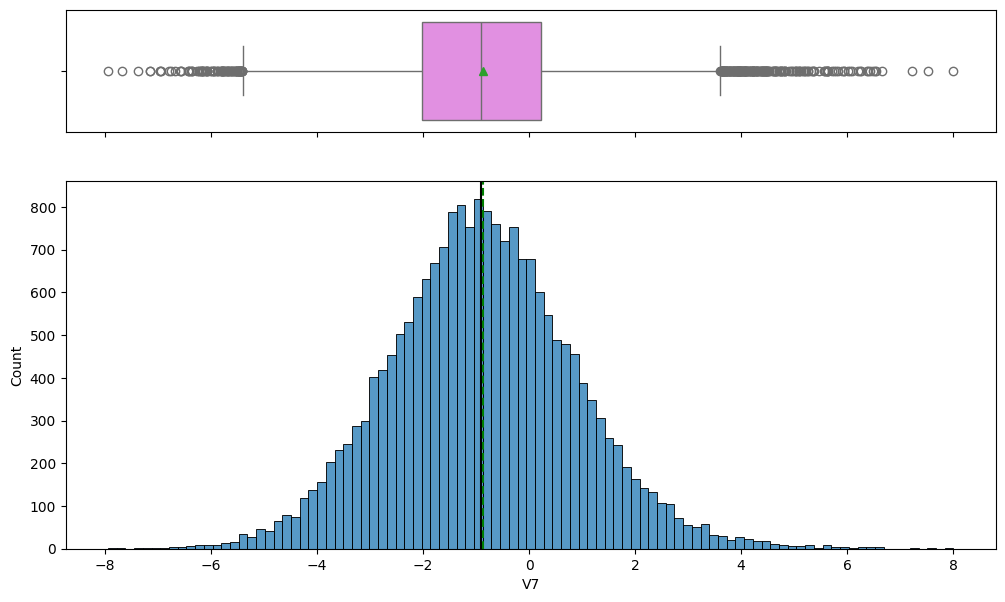

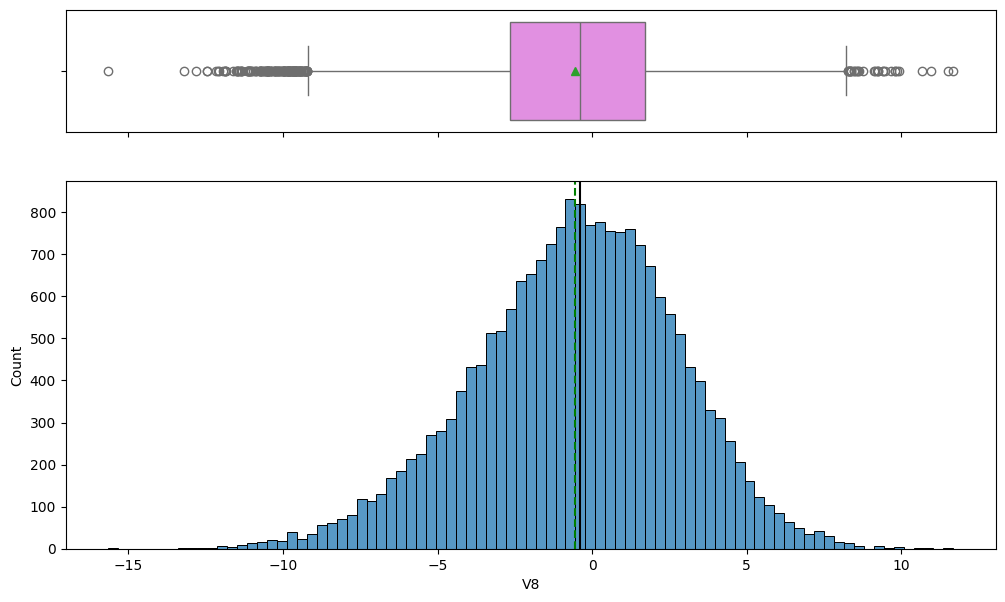

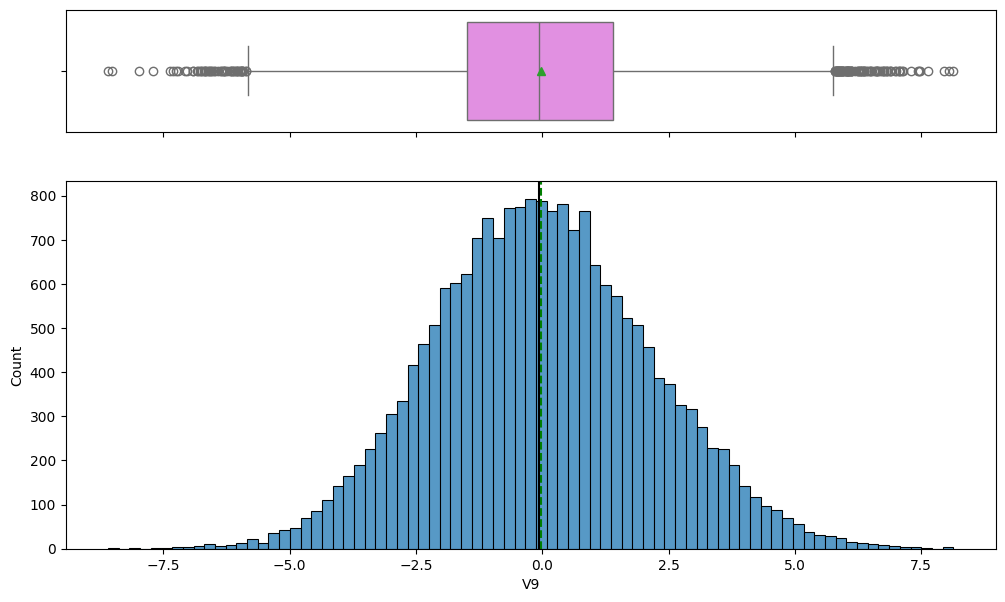

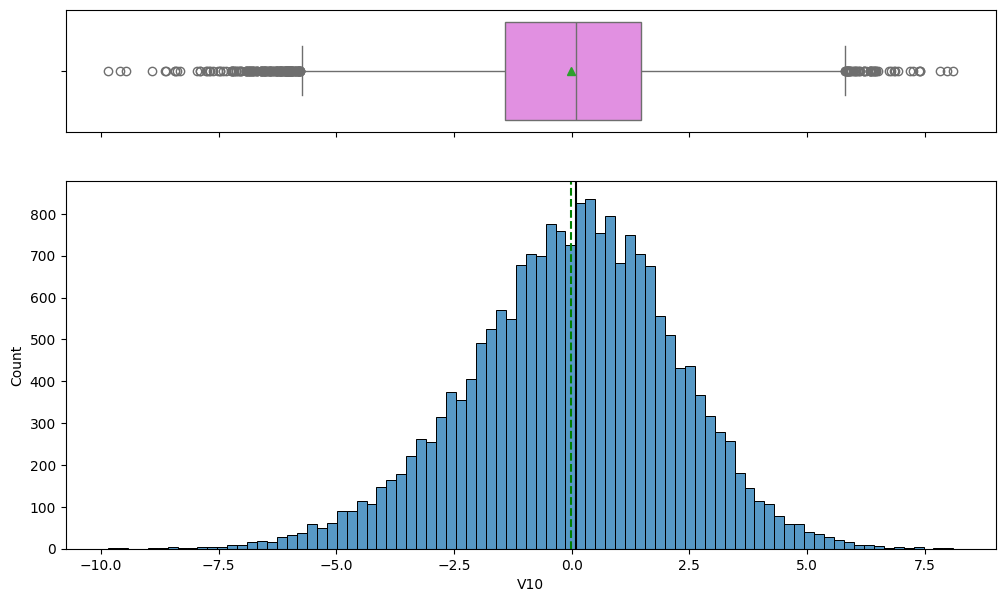

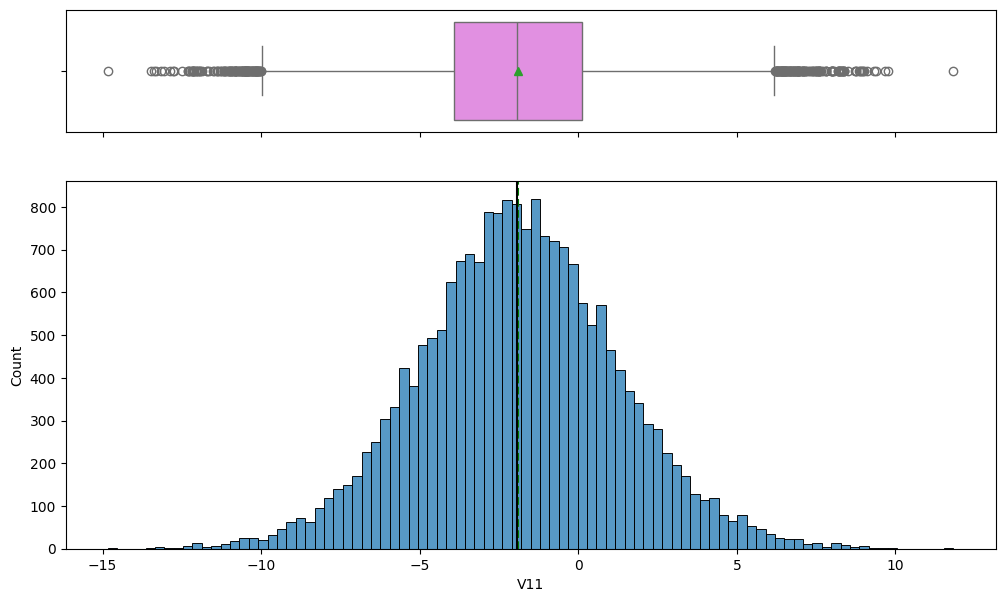

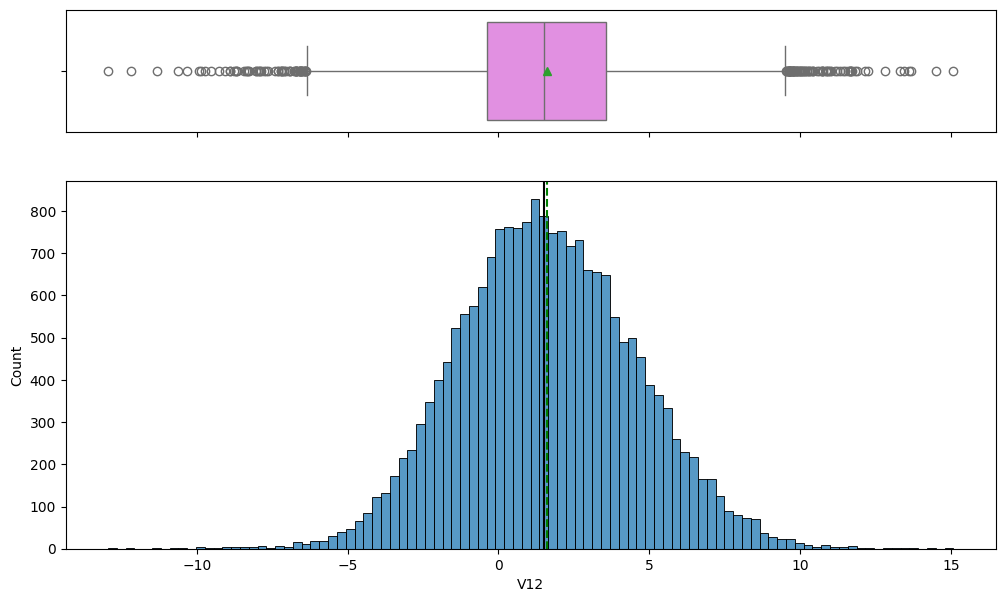

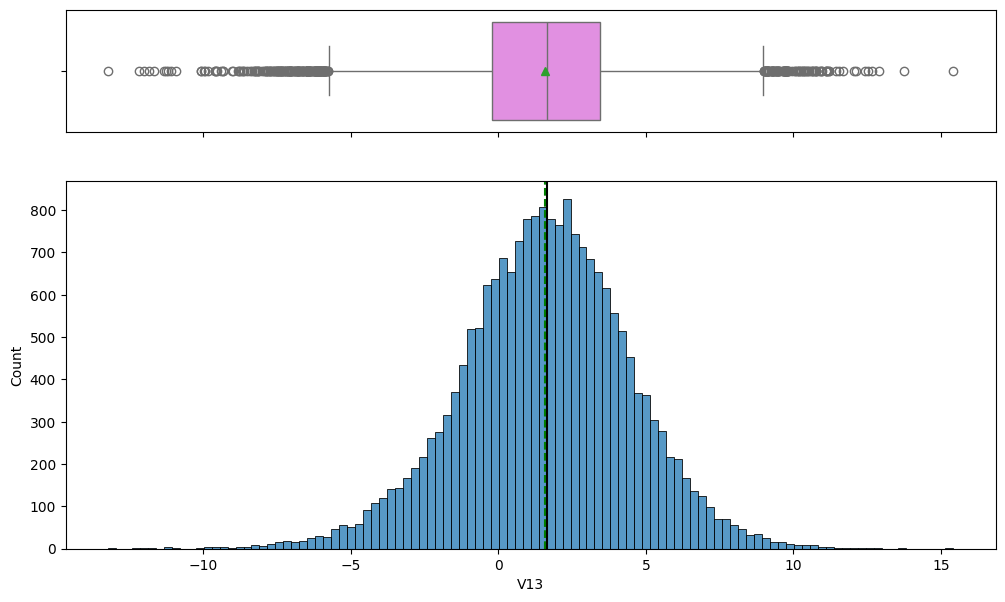

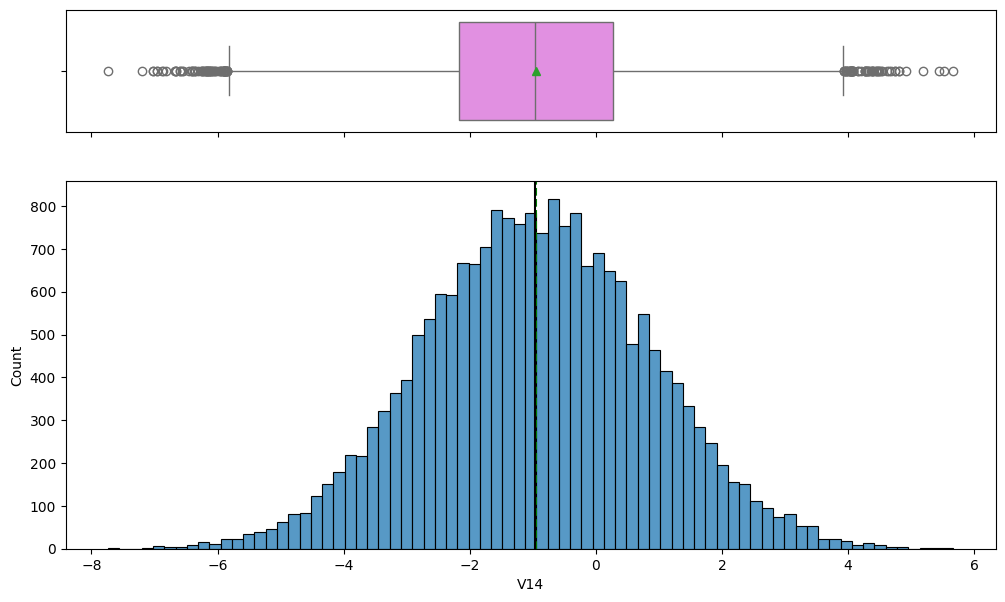

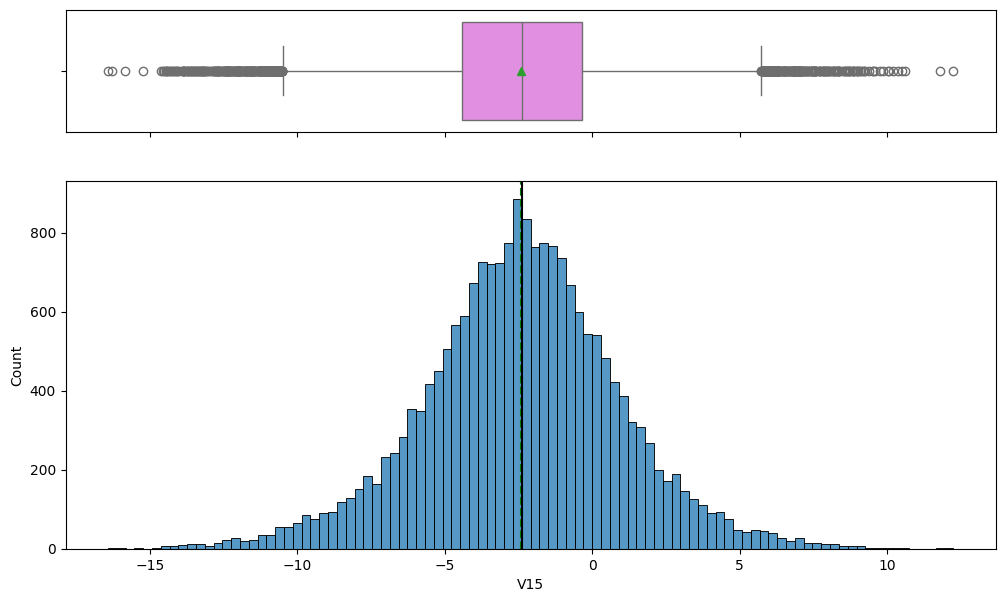

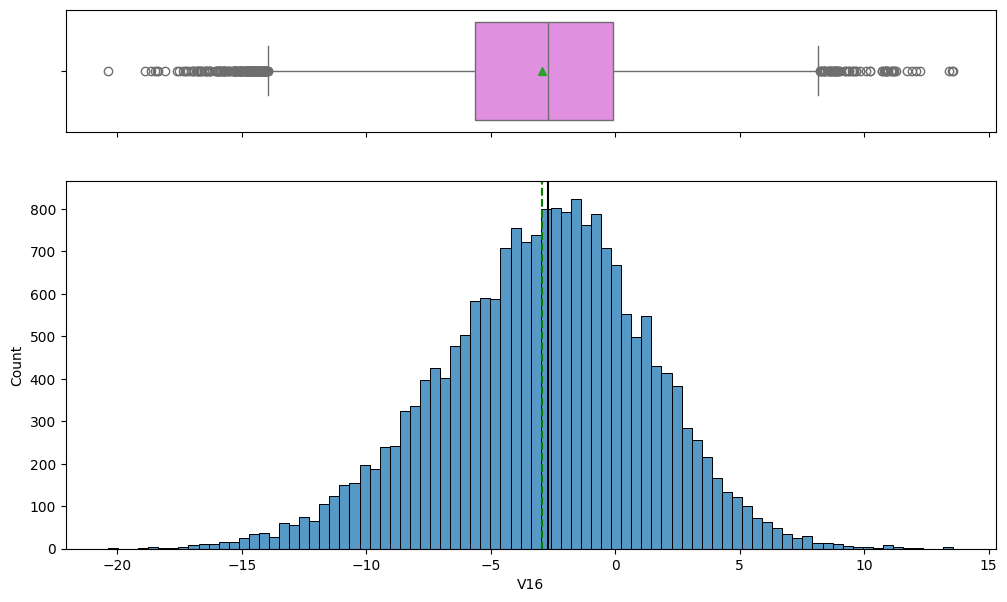

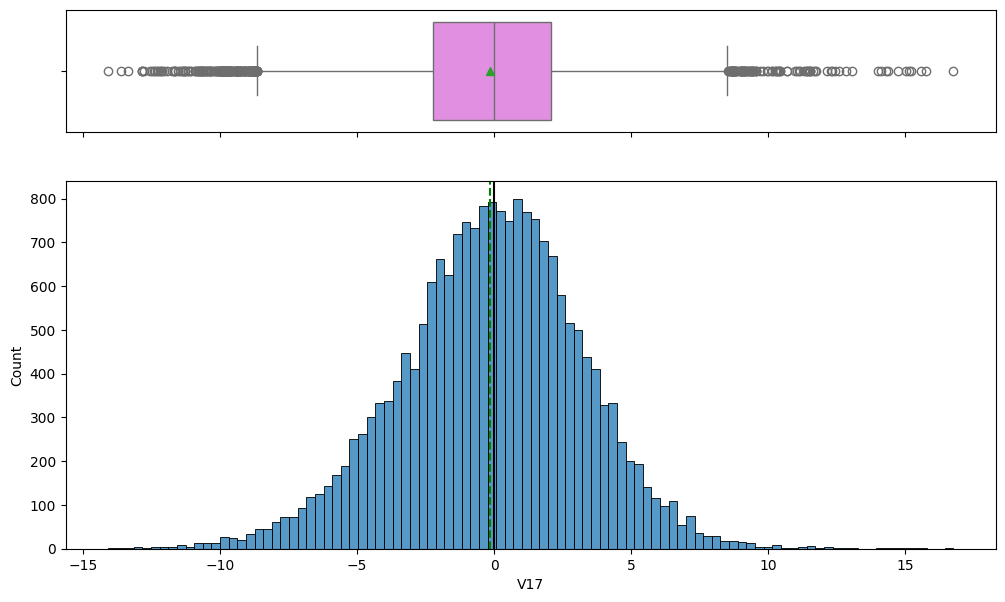

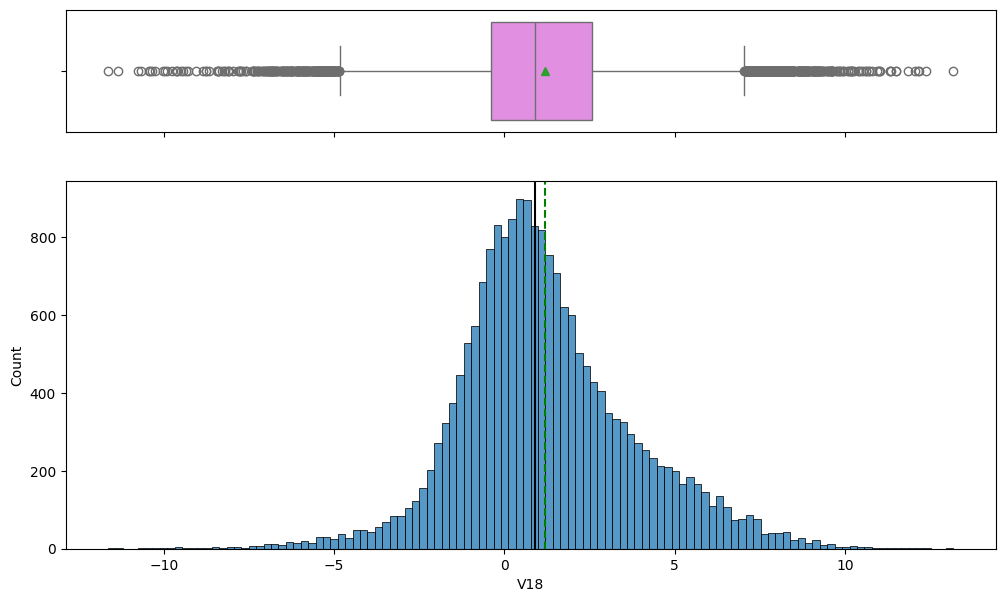

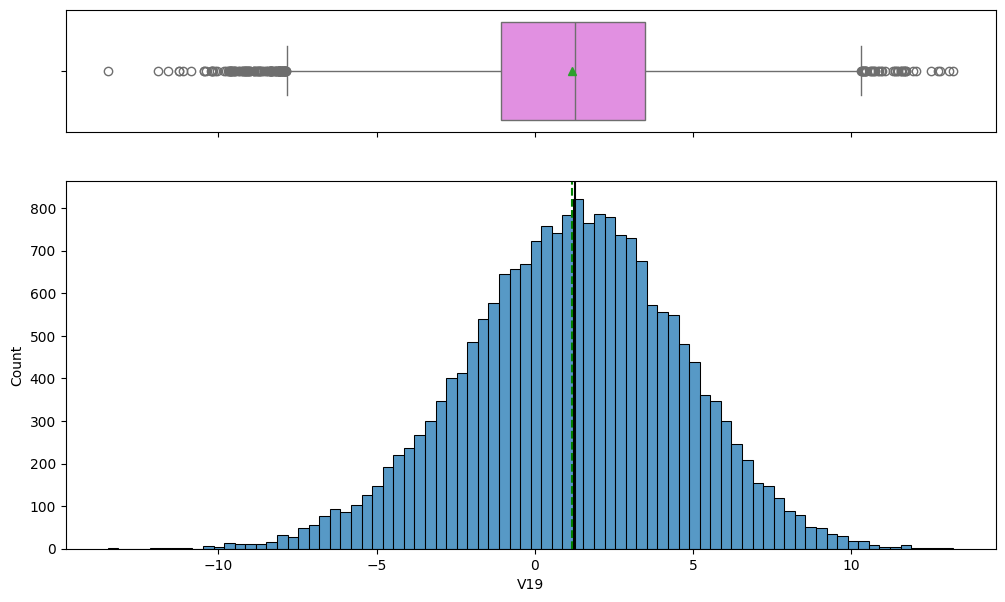

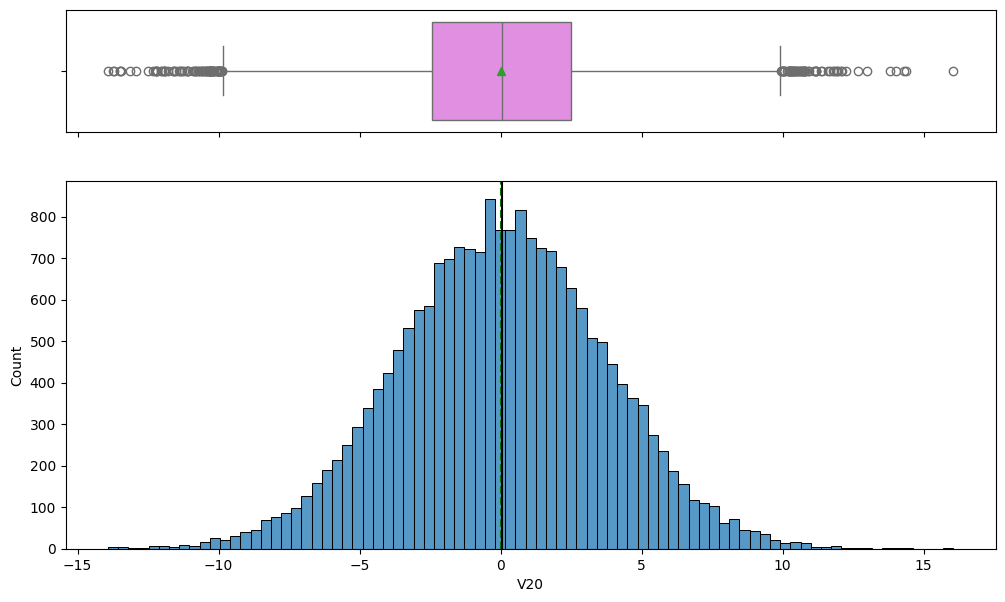

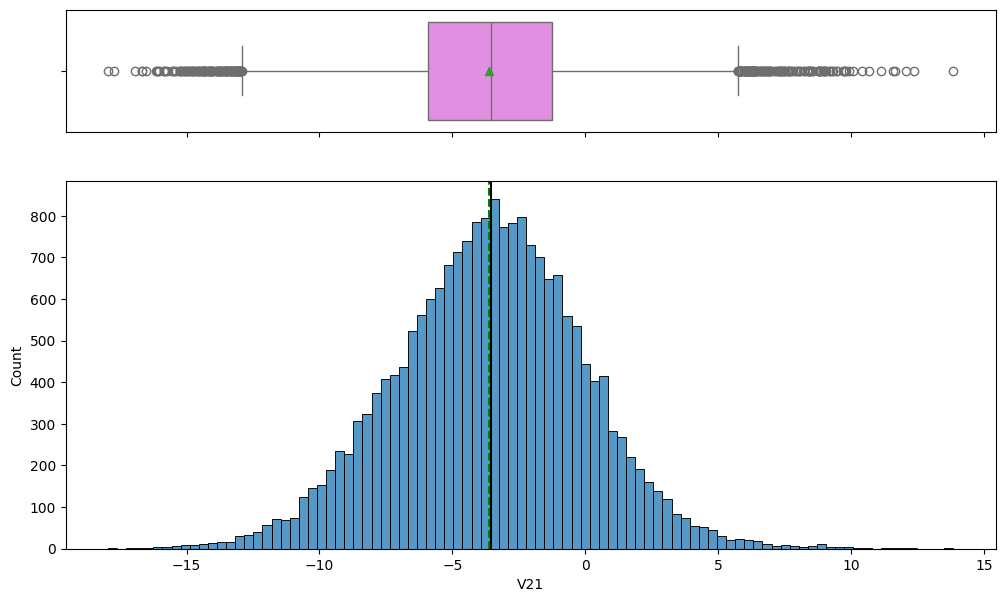

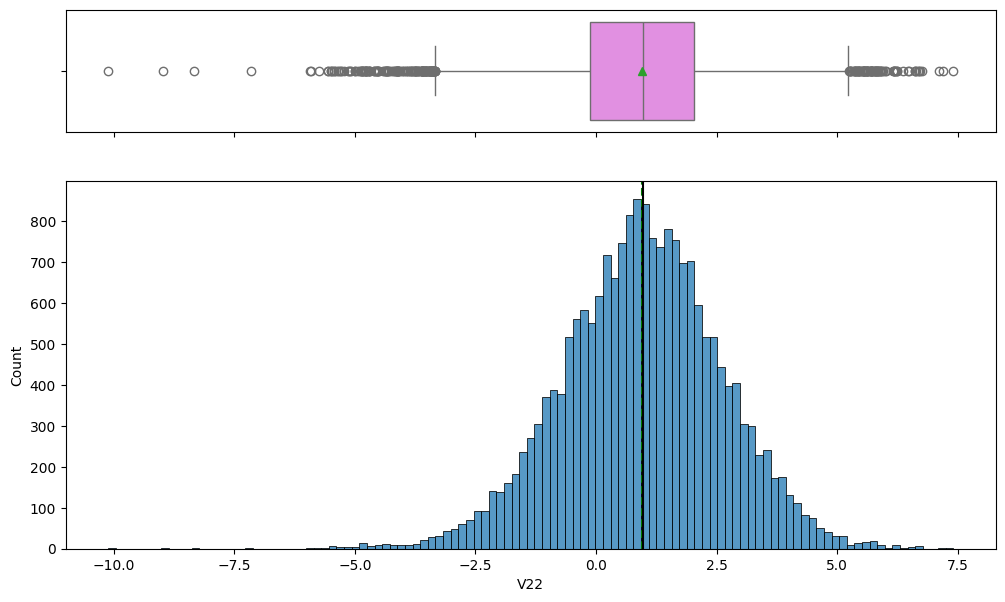

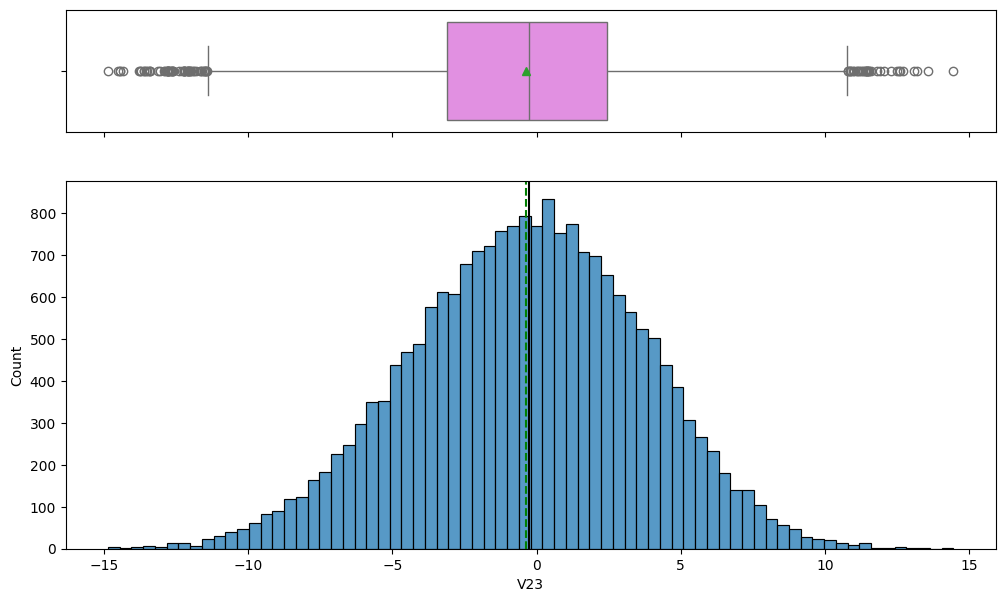

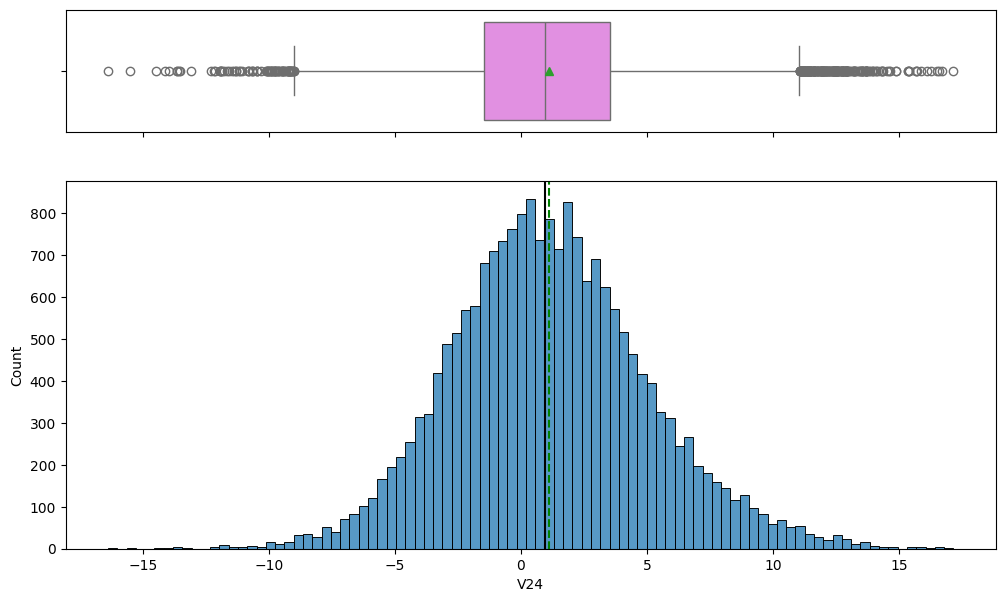

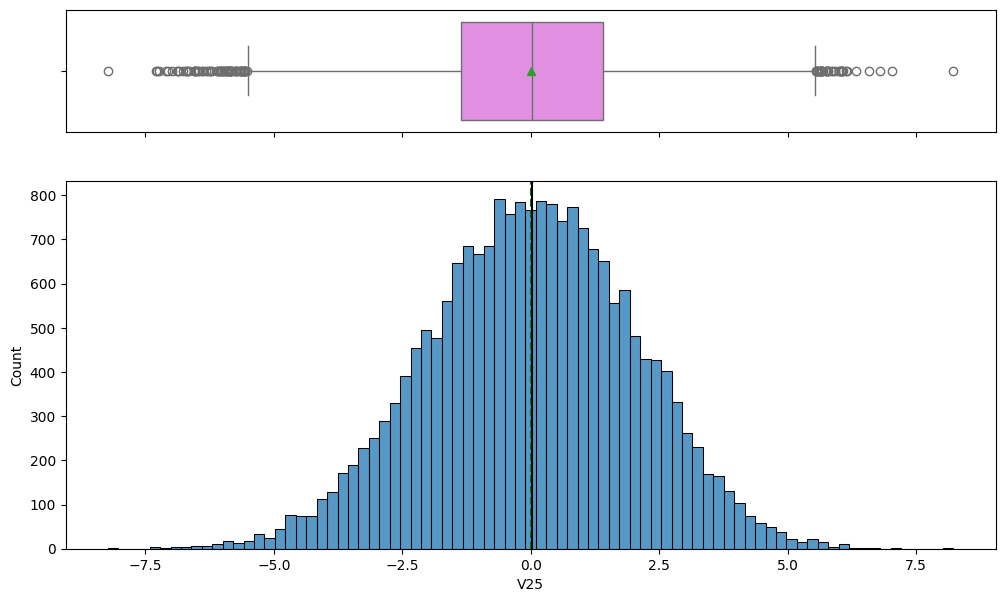

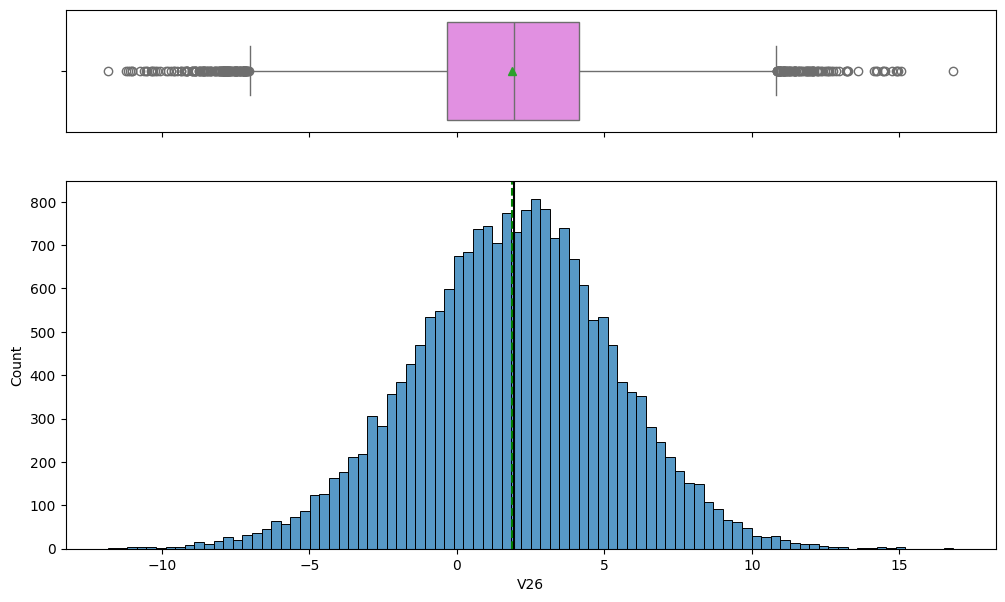

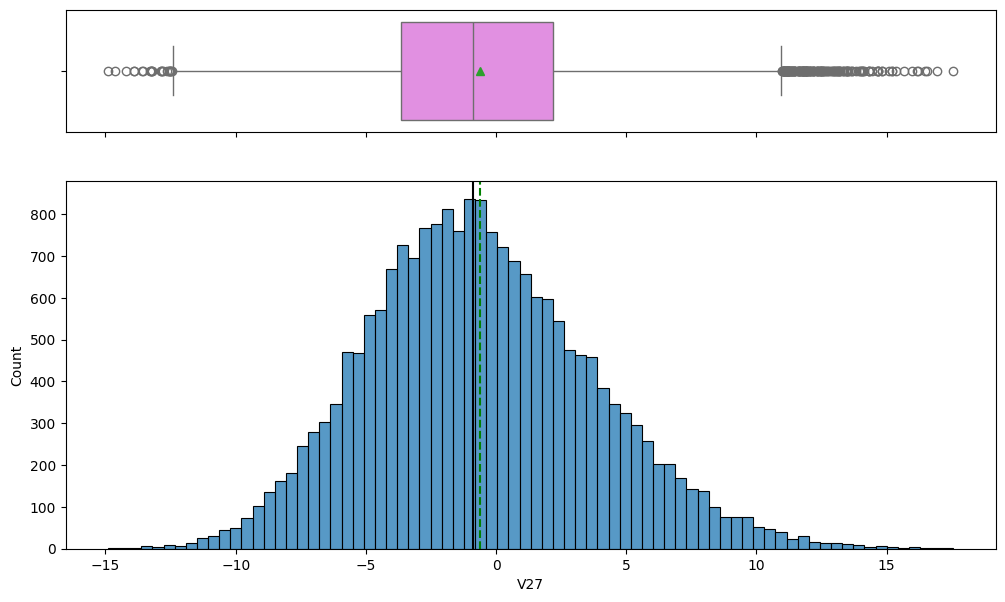

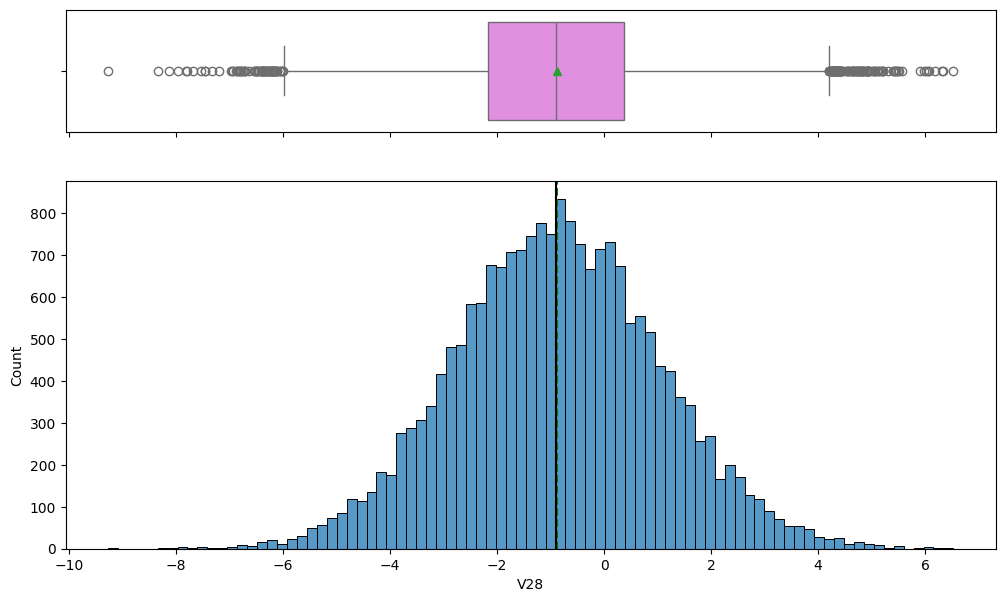

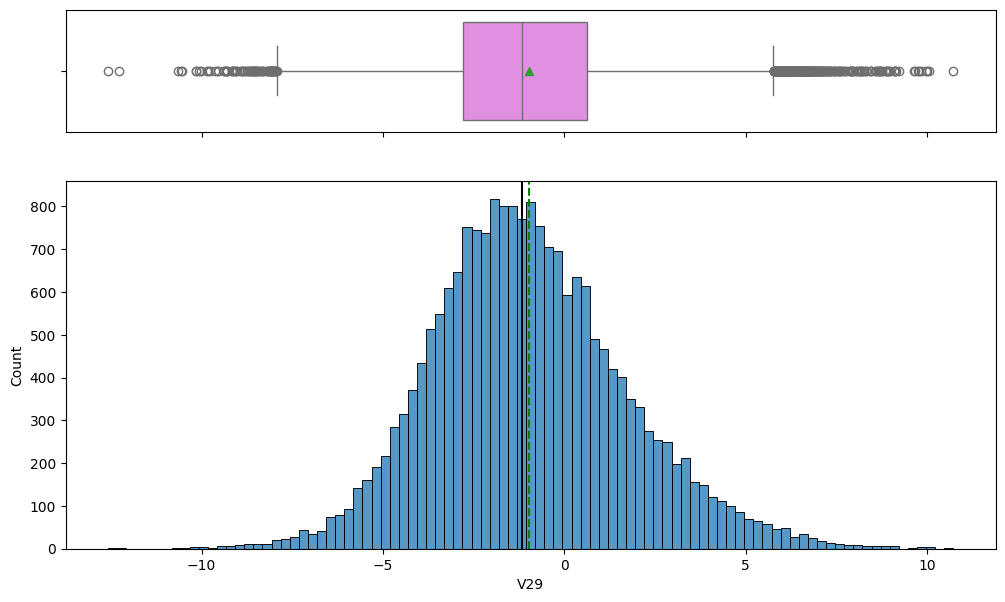

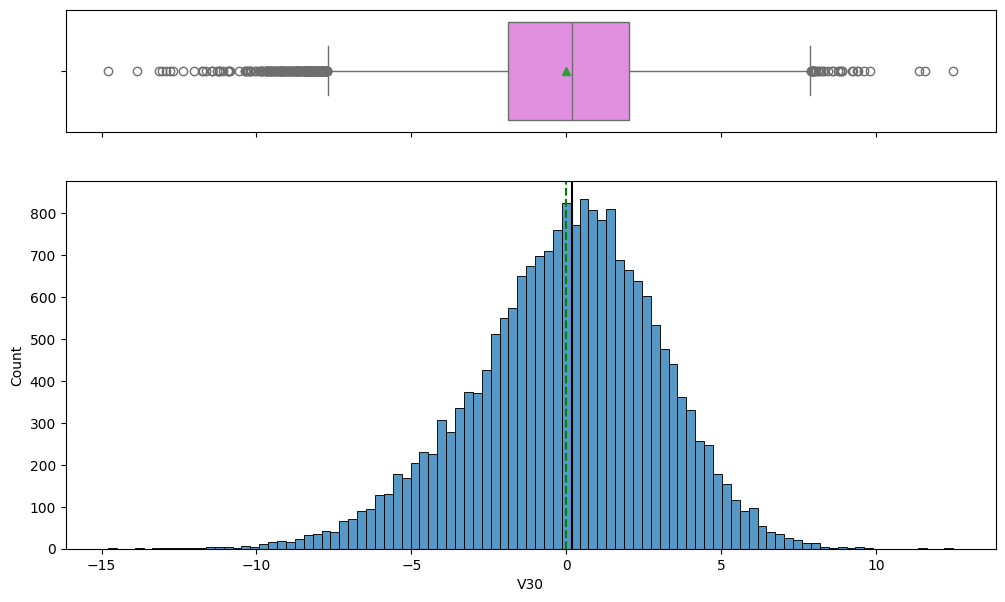

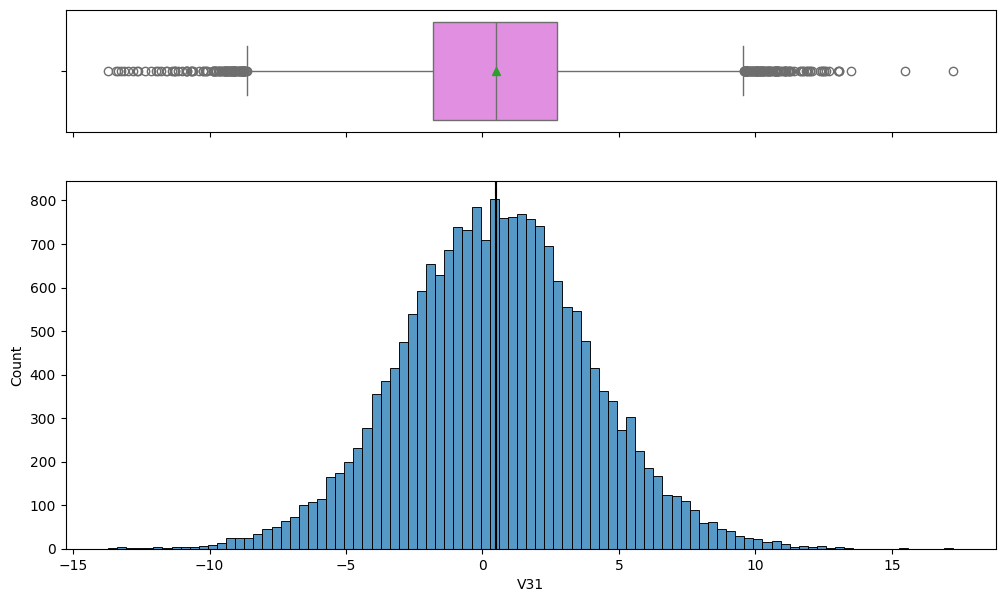

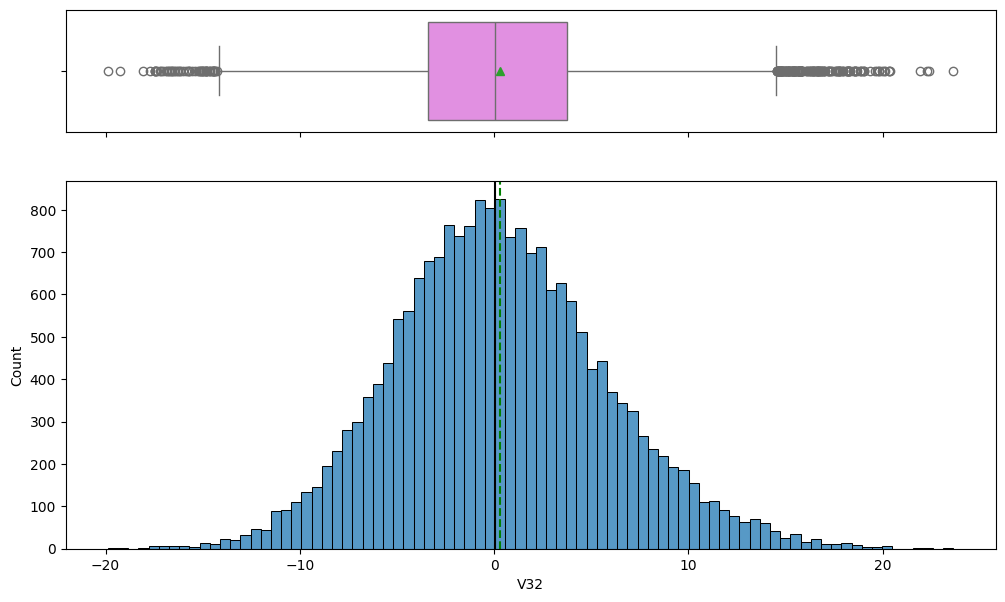

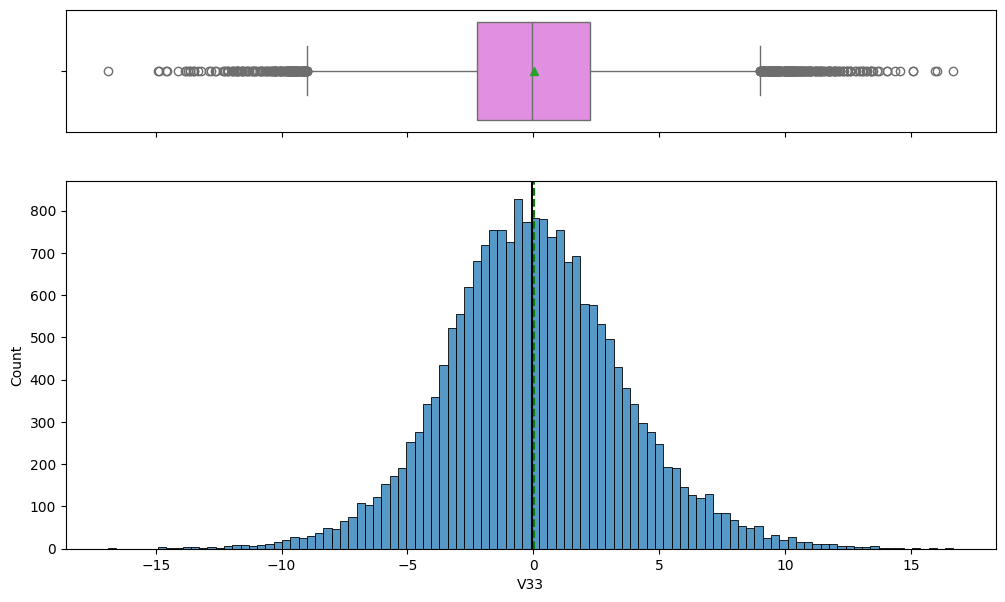

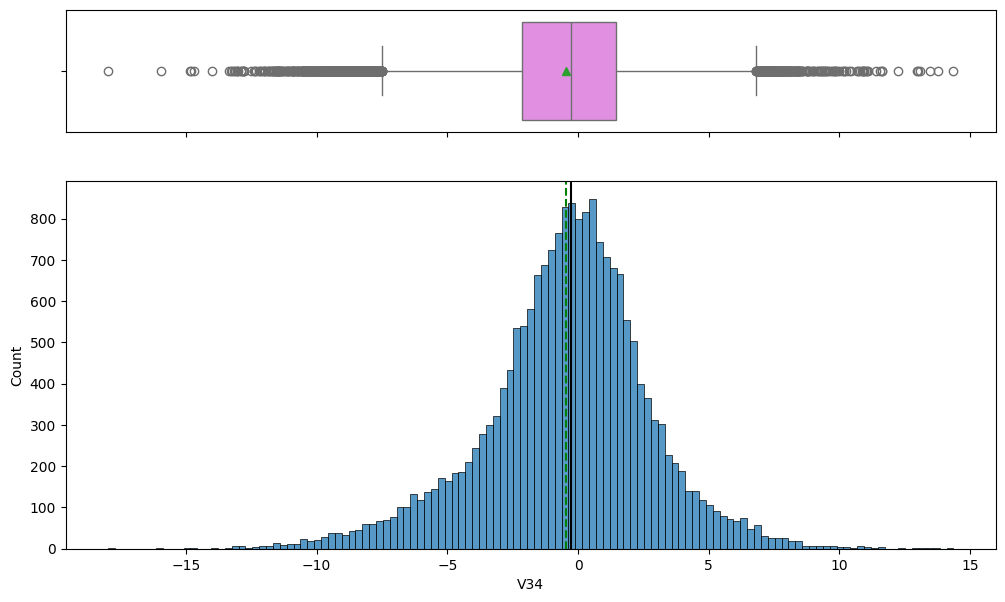

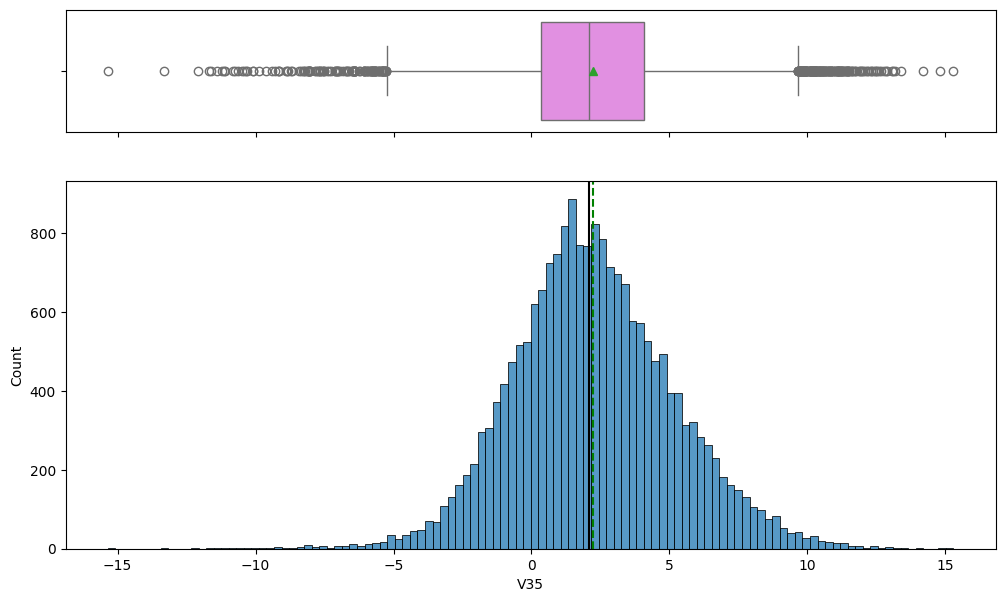

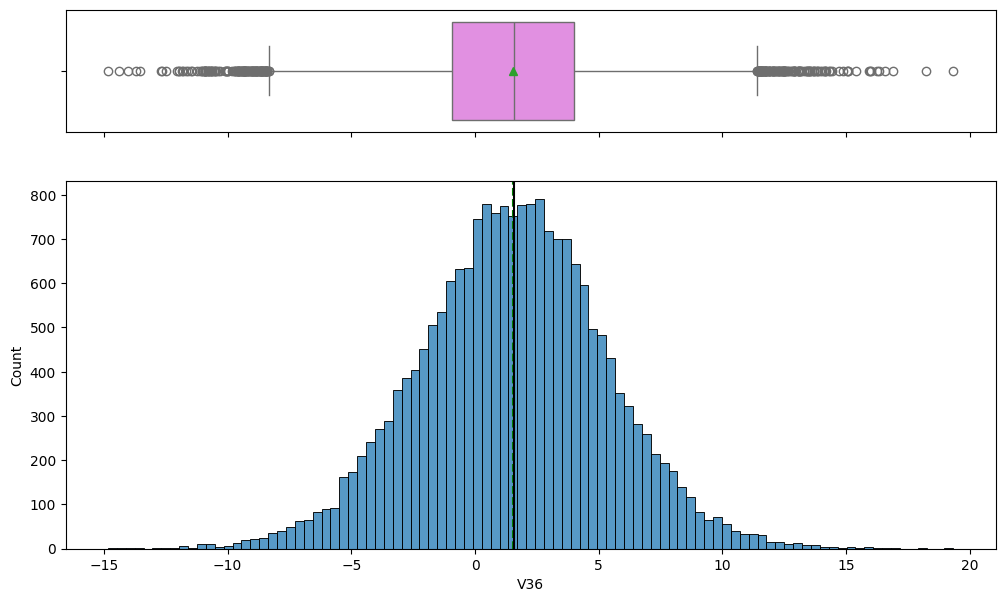

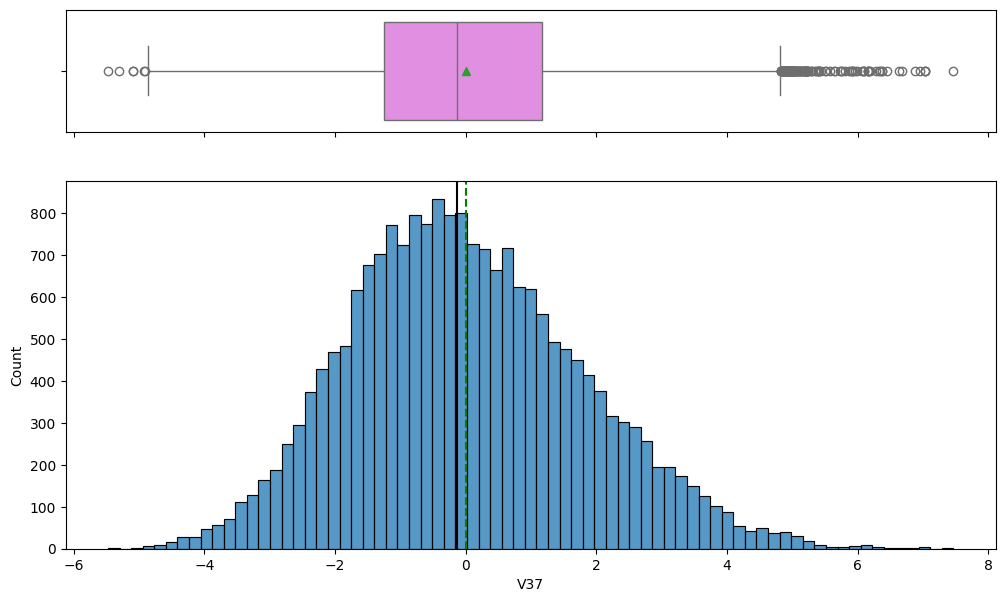

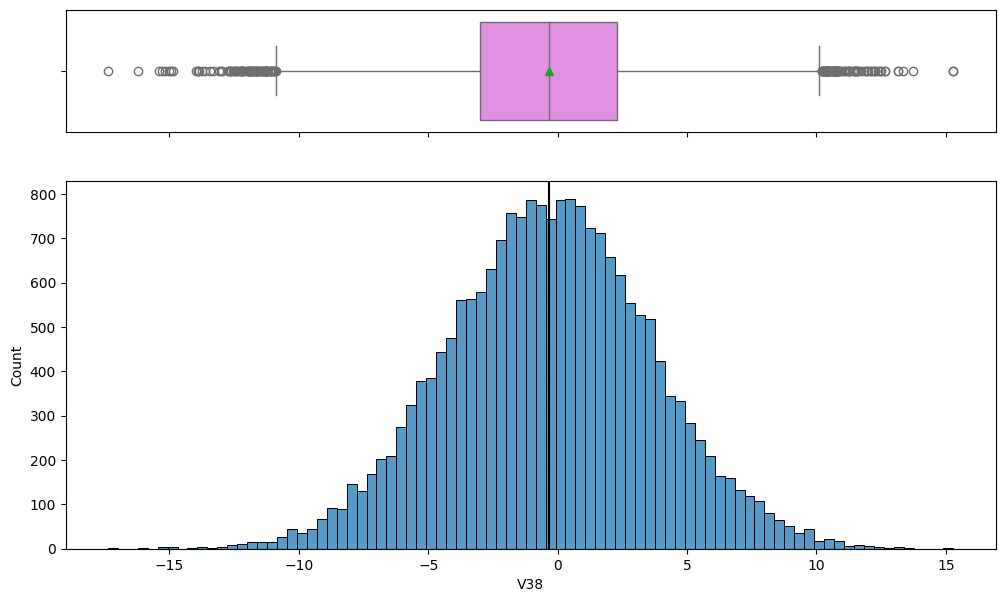

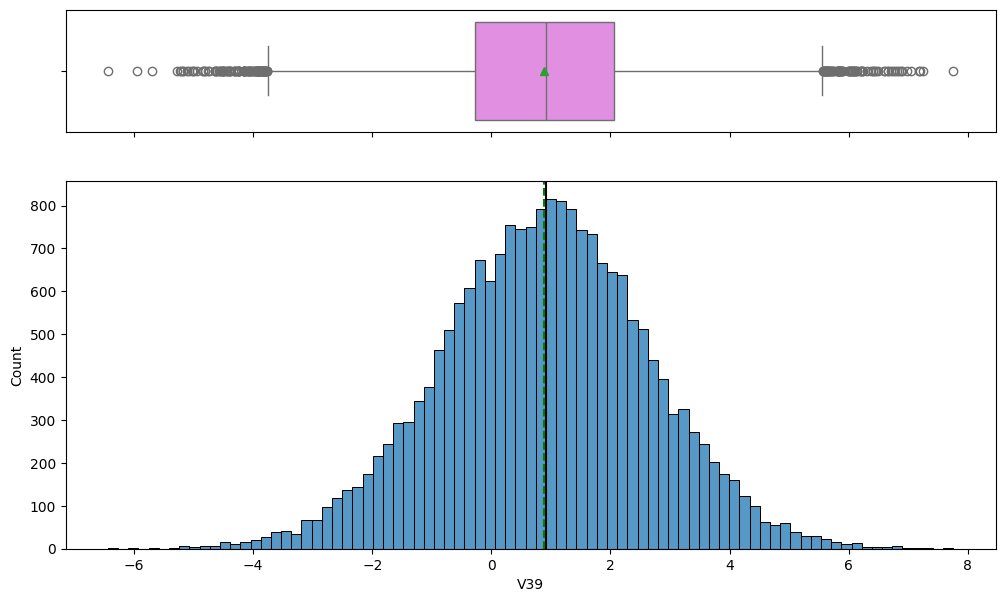

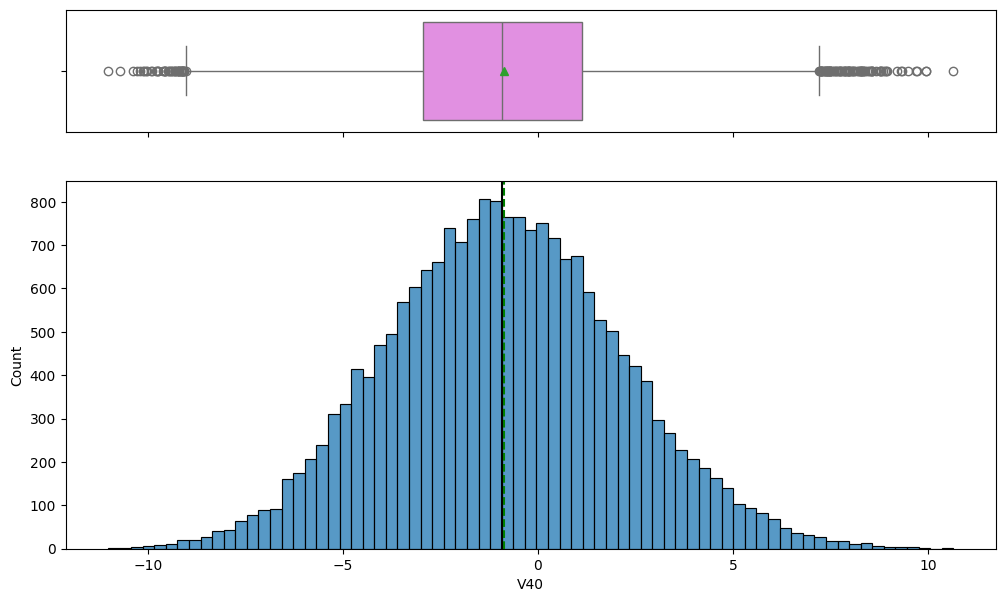

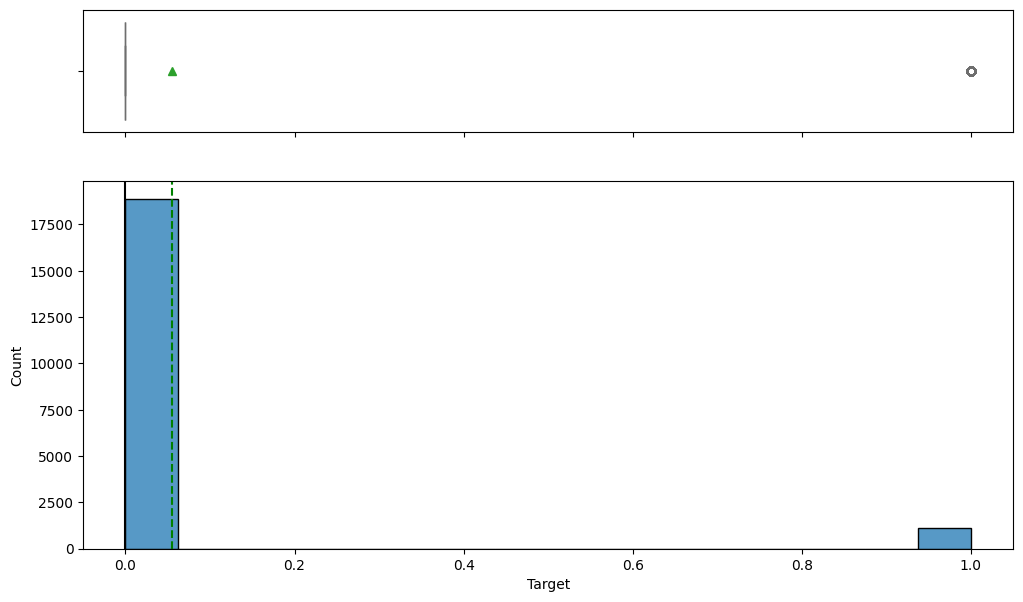

In [ ]:
for feature in data.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None) ## Please change the dataframe name as you define while reading the data

- Overall, all the feature columns have normal distributions with outliers. As these outliers appear to be from data collected from the various sensors, we will not treat/remove them.
- As the feature columns have normal distribution and there are no significant outliers, we will impute missing values with mean.
- Target column has significantly imbalanced class values.

## Data Pre-processing

In [5]:
# Separating features and the target column
X = data.drop('Target', axis=1)
y = data['Target']

X_test = data_test.drop('Target', axis=1)
y_test = data_test['Target']

### Split the data into train and validation sets
- Since we have been provided with two separate datasets (Train.csv and Test.csv), the Train.csv file can be split into training and validation sets to train, tune, and check how models perform. The Test.csv file should be used for testing the performance of the final model only.
- When data (classification) exhibit a significant imbalance in the distribution of the target classes, it is good to use stratified sampling to ensure that relative class frequencies are approximately preserved in train and validation sets.
- This is done by setting the stratify parameter to target variable in the train_test_split function.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)
print(X_train.shape, X_val.shape)

(15000, 40) (5000, 40)


- We have 15,000 observations in the train set and 5,000 observations in the test set.

## Missing value imputation




In [ ]:
# let's check for missing values in the data
data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


- There are 18 missing values in V1 and V2 columns.
- We will be imputing the missing values with mean in the data after splitting into train and validation.

In [7]:
imputer = SimpleImputer(strategy="mean")

In [8]:
# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

## Model Building

### Model evaluation criterion

The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model.
- False negatives (FN) are real failures in a generator where there is no detection by model.
- False positives (FP) are failure detections in a generator where there is no failure.

**Which metric to optimize?**

* We need to choose the metric which will ensure that the maximum number of generator failures are predicted correctly by the model.
* We would want Recall to be maximized as greater the Recall, the higher the chances of minimizing false negatives.
* We want to minimize false negatives because if a model predicts that a machine will have no failure when there will be a failure, it will increase the maintenance cost.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [9]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1
        },
        index=[0],
    )

    return df_perf

In [10]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Defining scorer to be used for cross-validation and hyperparameter tuning

- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [11]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

### Model Building with original data

Building 6 models with original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Logistic Regression", LogisticRegression(random_state = 1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

dtree: 0.6982829521679532
Bagging: 0.7210807301060529
Random forest: 0.7235192266070268
GBM: 0.7066661857008874
Adaboost: 0.5371329629896833
Logistic Regression: 0.4927566553639709

Validation Performance:

dtree: 0.7050359712230215
Bagging: 0.7302158273381295
Random forest: 0.7266187050359713
GBM: 0.7230215827338129
Adaboost: 0.6007194244604317
Logistic Regression: 0.4856115107913669


- We can see that Bagging is giving the highest cross-validated recall followed by Random forest and GBM

### Model Building with Oversampled data


In [14]:
# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

In [ ]:
models1 = []  # Empty list to store all the models

# Appending models into the list
models1.append(("dtree1", DecisionTreeClassifier(random_state=1)))
models1.append(("Bagging1", BaggingClassifier(random_state=1)))
models1.append(("Random forest1", RandomForestClassifier(random_state=1)))
models1.append(("GBM1", GradientBoostingClassifier(random_state=1)))
models1.append(("Adaboost1", AdaBoostClassifier(random_state=1)))
models1.append(("Logistic Regression1", LogisticRegression(random_state = 1)))

results1 = []  # Empty list to store all model's CV scores
names1 = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance on Training Dataset with Oversampling:" "\n")

for name, model in models1:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result1 = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scorer, cv=kfold
    )
    results1.append(cv_result1)
    names1.append(name)
    print("{}: {}".format(name, cv_result1.mean()))

print("\n" "Validation Performance: with Oversampling" "\n")

for name, model in models1:
    model.fit(X_train_over, y_train_over)
    scores1 = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores1))


Cross-Validation Performance on Training Dataset with Oversampling:

dtree1: 0.9720494245534969
Bagging1: 0.9762141471581656
Random forest1: 0.9839781474560958
GBM1: 0.9256068151319724
Adaboost1: 0.891445687121811
Logistic Regression1: 0.883963699328486

Validation Performance: with Oversampling

dtree1: 0.7769784172661871
Bagging1: 0.8345323741007195
Random forest1: 0.841726618705036
GBM1: 0.8776978417266187
Adaboost1: 0.8597122302158273
Logistic Regression1: 0.8489208633093526


- GBM is giving the highest recall score on validation datasets, followed by Adaboost and Logistic Regression.

### Model Building with Undersampled data

In [13]:
# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
models2 = []  # Empty list to store all the models

# Appending models into the list
models2.append(("dtree2", DecisionTreeClassifier(random_state=1)))
models2.append(("Bagging2", BaggingClassifier(random_state=1)))
models2.append(("Random forest2", RandomForestClassifier(random_state=1)))
models2.append(("GBM2", GradientBoostingClassifier(random_state=1)))
models2.append(("Adaboost2", AdaBoostClassifier(random_state=1)))
models2.append(("Logistic Regression2", LogisticRegression(random_state = 1)))

results2 = []  # Empty list to store all model's CV scores
names2 = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance on Training Dataset with Undersampling:" "\n")

for name, model in models2:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result2 = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scorer, cv=kfold
    )
    results2.append(cv_result2)
    names2.append(name)
    print("{}: {}".format(name, cv_result2.mean()))

print("\n" "Validation Performance with Undersampling:" "\n")

for name, model in models2:
    model.fit(X_train_un, y_train_un)
    scores2 = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores2))


Cross-Validation Performance on Training Dataset with Undersampling:

dtree2: 0.8617776495202367
Bagging2: 0.8641945025611427
Random forest2: 0.9038669648654498
GBM2: 0.8978572974532861
Adaboost2: 0.8665969266286705
Logistic Regression2: 0.8726138085275232

Validation Performance with Undersampling:

dtree2: 0.841726618705036
Bagging2: 0.8705035971223022
Random forest2: 0.8920863309352518
GBM2: 0.8884892086330936
Adaboost2: 0.8633093525179856
Logistic Regression2: 0.8525179856115108


- Random forest is giving the highest recall score on validation datasets, followed by GBM and Bagging.

- The top models with the highest recall scores on validation datasets are Random forest and GBM with undersampled datasets and Bagging with oversampled datasets. We will tune these 3 models using RandomizedSearchCV and see if the performance improves.

## HyperparameterTuning

### Sample Parameter Grids

**Hyperparameter tuning can take a long time to run, so to avoid that time complexity - you can use the following grids, wherever required.**

- For Gradient Boosting:

param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

- For Adaboost:

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.2, 0.05],
    "base_estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

- For Bagging Classifier:

param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

- For Random Forest:

param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

- For Decision Trees:

param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

- For Logistic Regression:

param_grid = {'C': np.arange(0.1,1.1,0.1)}

- For XGBoost:

param_grid={
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5,10],
    'learning_rate': [0.1,0.2],
    'gamma': [0,3,5],
    'subsample': [0.8,0.9]
}

### Hyperparameter tuning method for Random forest with undersampled data

In [20]:
# defining model
model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 250, 'min_samples_leaf': 1, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.8978140105331505:


In [21]:
# building model with best parameters
rf_tuned = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=1,
    max_samples=0.6,
    max_features='sqrt',
)

# Fit the model on undersampled training data
rf_tuned.fit(X_train_un, y_train_un)

RandomForestClassifier(max_samples=0.6, n_estimators=250)

In [22]:
# Calculating different metrics on undersampled train set
rf_random_train_un = model_performance_classification_sklearn(
    rf_tuned, X_train_un, y_train_un
)
print("Training performance:")
rf_random_train_un

Training performance:


,Accuracy,Recall,Precision,F1
0,0.989,0.978,1.000,0.989


In [23]:
# Calculating different metrics on validation set
rf_random_val = model_performance_classification_sklearn(rf_tuned, X_val, y_val)
print("Validation performance:")
rf_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.942,0.885,0.486,0.628


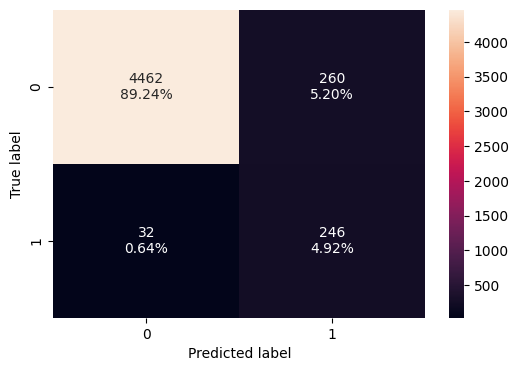

In [24]:
# creating confusion matrix
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

- The validation recall is similar to cross-validated recall
- The tuned Random forest model is slightly overfitting the undersampled training data

### Hyperparameter tuning method for Gradient Boosting with undersampled data

In [25]:
# defining model
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(100,150,25),
    "learning_rate": [0.2, 0.05, 1],
    "subsample":[0.5,0.7],
    "max_features":[0.5,0.7]
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 0.2} with CV score=0.9002164346006782:


In [26]:
# building model with best parameters
tuned_gbm = GradientBoostingClassifier(
    subsample=0.5,
    n_estimators=125,
    max_features=0.5,
    learning_rate=0.2,
)

# Fit the model on undersampled training data
tuned_gbm.fit(X_train_un, y_train_un)

GradientBoostingClassifier(learning_rate=0.2, max_features=0.5,
                           n_estimators=125, subsample=0.5)

In [27]:
# Calculating different metrics on undersampled train set
gbm_random_train_un = model_performance_classification_sklearn(
    tuned_gbm, X_train_un, y_train_un
)
gbm_random_train_un

,Accuracy,Recall,Precision,F1
0,0.993,0.987,0.999,0.993


In [28]:
# Calculating different metrics on validation set
gbm_random_val = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)
gbm_random_val

,Accuracy,Recall,Precision,F1
0,0.909,0.888,0.368,0.520


- The GBM model on RandomizedSearchCV is slightly overfitting
- The validation recall score is ~89%.

### Hyperparameter tuning method for Bagging with oversampled data

In [15]:
# defining model
model = BaggingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.8} with CV score=0.9827782553686626:


In [16]:
# building model with best parameters
bagging_tuned = BaggingClassifier(
    n_estimators=70,
    max_samples=0.9,
    max_features=0.8,
)

# Fit the model on oversampled training data
bagging_tuned.fit(X_train_over, y_train_over)

BaggingClassifier(max_features=0.8, max_samples=0.9, n_estimators=70)

In [17]:
## To check the performance on oversampled training set
bagging_random_train_over = model_performance_classification_sklearn(
    bagging_tuned, X_train_over, y_train_over
)
bagging_random_train_over

,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [18]:
## To check the performance on validation set
bagging_random_val = model_performance_classification_sklearn(
    bagging_tuned, X_val, y_val
)
bagging_random_val

,Accuracy,Recall,Precision,F1
0,0.986,0.867,0.883,0.875


- The Bagging model on RandomizedSearchCV is slightly overfitting the oversampled train set
- The recall score is comparable to tuned random forest and gradient boosting.
- When compared with random forest and gradient boosting models, the tuned bagging model is giving best overall performance on accuracy, precision, and f1 scores.

## Model performance comparison and choosing the final model

In [29]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        rf_random_train_un.T,
        gbm_random_train_un.T,
        bagging_random_train_over.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Random Forest Tuned with Random search",
    "Gradient Boosting Tuned with Random search",
    "Bagging Tuned with Random search",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Tuned with Random search,Gradient Boosting Tuned with Random search,Bagging Tuned with Random search
Accuracy,0.989,0.993,1.000
Recall,0.978,0.987,1.000
Precision,1.000,0.999,1.000
F1,0.989,0.993,1.000


In [30]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        rf_random_val.T,
        gbm_random_val.T,
        bagging_random_val.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Random Forest Tuned with Random search",
    "Gradient Boosting Tuned with Random search",
    "Bagging Tuned with Random search",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Random Forest Tuned with Random search,Gradient Boosting Tuned with Random search,Bagging Tuned with Random search
Accuracy,0.942,0.909,0.986
Recall,0.885,0.888,0.867
Precision,0.486,0.368,0.883
F1,0.628,0.520,0.875


- The Gradient Boosting model tuned using random search is giving the best validation recall of 0.888 but it has the lower values of train and validation precision than Bagging model tuned with random search.
- Since the Bagging model tuned using random search is giving the best overall scores, we will choose this model as the final model.
- Let's check the Bagging model's performance on test set.

### Test set final performance

In [31]:
# Calculating different metrics on the test set
bagging_random_test = model_performance_classification_sklearn(bagging_tuned, X_test, y_test)
print("Test performance:")
bagging_random_test

Test performance:


,Accuracy,Recall,Precision,F1
0,0.985,0.823,0.903,0.861


- The performance on test data is generalized
- Let's check the important features for prediction using the random forest model since bagging classifier does not provide a feature importance attribute.

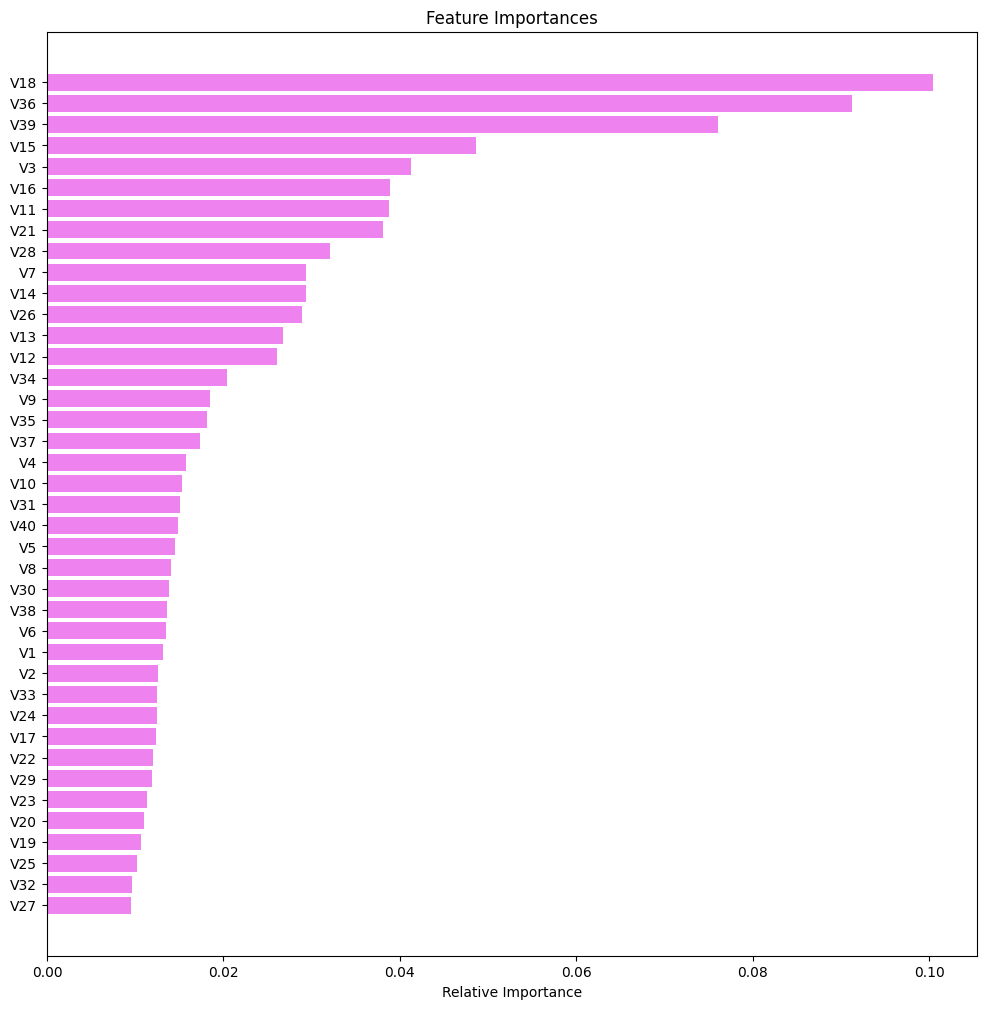

In [32]:
feature_names = X.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- V18 is the most important feature, followed by V36 and V39.

## Pipelines to build the final model


Now that we have a final model, let's use pipelines to put the model into production. We know that we can use pipelines to standardize the model building, but the steps in a pipeline are applied to each and every variable.

How can we personalize the pipeline to perform different preprocessing steps on different columns? - **By using Column Transformer**

**Column Transformer**

- Column Transformer allows different columns or column subsets of the input to be transformed separately and the features generated by each transformer will be concatenated to form a single feature space
- This is useful for heterogeneous or columnar data to combine several feature extraction mechanisms or transformations into a single transformer

We will create the following pipeline for numerical columns
- For numerical columns, we will do missing value imputation as pre-processing

**Note**: We will be doing missing value imputation for the whole data so that if there are any missing values in the data in future, they can be taken care of

In [33]:
# creating a list of numerical variables
numerical_features = [
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
    "V7",
    "V8",
    "V9",
    "V10",
    "V11",
    "V12",
    "V13",
    "V14",
    "V15",
    "V16",
    "V17",
    "V18",
    "V19",
    "V21",
    "V22",
    "V23",
    "V24",
    "V25",
    "V26",
    "V27",
    "V28",
    "V29",
    "V30",
    "V31",
    "V32",
    "V33",
    "V34",
    "V35",
    "V36",
    "V37",
    "V38",
    "V39",
    "V40",
]

# creating a transformer for numerical variables, which will apply simple imputer on the numerical variables
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

In [34]:
# creating a pipleline for numerical transformer using a column transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
    ],
    remainder="passthrough",
)

In [36]:
# Separating target variable and other variables
X = data.drop(columns="Target")
y = data["Target"]

- Now we already know the best model we need to process with, so we don't need to divide data into 3 parts
- Since we are given 2 separate files for train and test sets, we do not need to split the data into train and test sets.

In [37]:
# Setting up test and train datasets
X_train = X
y_train = y

X_test = data_test.drop('Target', axis=1)
y_test = data_test['Target']

In [38]:
# Creating new pipeline with best parameters
model = Pipeline(
    steps=[
        ("pre", preprocessor),
        (
            "Bagging",
            BaggingClassifier(
                n_estimators=70,
                max_samples=0.9,
                max_features=0.8,
        ),
        ),
    ]
)
# Fit the model on training data
model.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['V1', 'V2', 'V3', 'V4', 'V5',
                                                   'V6', 'V7', 'V8', 'V9',
                                                   'V10', 'V11', 'V12', 'V13',
                                                   'V14', 'V15', 'V16', 'V17',
                                                   'V18', 'V19', 'V21', 'V22',
                                                   'V23', 'V24', 'V25', 'V26',
                                                   'V27', 'V28', 'V29', 'V30',
                                                   'V31', ...])])),
                ('Bagging',
                 BaggingClassifier(max_features=0.8, max_samples=0.9,
                                   n_estimators=70))])

In [39]:
# Let's check the performance on test set
model_test = model_performance_classification_sklearn(model, X_test, y_test)
model_test

,Accuracy,Recall,Precision,F1
0,0.983,0.734,0.958,0.831


# Business Insights and Conclusions

***

Based on the model results, the following business insights are presented for ReneWind to minimize maintenance costs and enhance operational efficiency in wind energy production:

**1. Deploy the Bagging Model for Predictive Maintenance**
- The Bagging model, having the best overall performance, should be implemented for predicting generator failures.
- Regular model updates with new sensor data should be performed to maintain accuracy.

**2. Focus on Key Predictors for Maintenance Strategy**
- V18, V36, and V39 have been identified as the most influential features in predicting failures.
- Sensor data related to these features should be monitored in real-time to enable proactive decision-making.